# ANN - Dự báo Thu nhập >50K hay <=50K (Adult / Census Income)

| Thông tin | Chi tiết |
|-----------|---------|
| **Dataset** | UCI Adult (Census Income) — 48,842 mẫu |
| **Nguồn** | UCI Machine Learning Repository, id=2 |
| **Mục tiêu** | Phân loại nhị phân: thu nhập `>50K` hay `<=50K` mỗi năm |
| **Mô hình** | Artificial Neural Network (ANN) — Keras/TensorFlow |
| **Features** | 14 đặc trưng (số + phân loại), trong đó có missing values |


In [1]:
# ============================================================
# Cell 1: Cài đặt thư viện
# ------------------------------------------------------------
# ucimlrepo  : tải dataset thẳng từ UCI, không cần tải file tay
# tensorflow : xây dựng và train mô hình ANN
# scikit-learn: tiền xử lý, đánh giá mô hình
# imbalanced-learn: xử lý mất cân bằng nhãn (SMOTE)
# ============================================================

!pip install ucimlrepo tensorflow scikit-learn imbalanced-learn pandas numpy matplotlib seaborn -q
print("Cài đặt hoàn tất!")


Cài đặt hoàn tất!


In [2]:
# ============================================================
# Cell 2: Import thư viện
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from ucimlrepo import fetch_ucirepo

# Tiền xử lý
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (classification_report, confusion_matrix,
                             accuracy_score, roc_auc_score, roc_curve)

# Xử lý mất cân bằng nhãn
from imblearn.over_sampling import SMOTE

# ANN
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# Tái lập kết quả
np.random.seed(42)
tf.random.set_seed(42)

print(f"TensorFlow: {tf.__version__}")
print("Import thành công!")


TensorFlow: 2.20.0
Import thành công!


## 1. Tải và Khám phá Dữ liệu

In [3]:
# ============================================================
# Cell 3: Tải dataset Adult từ UCI (id=2)
# ------------------------------------------------------------
# Dataset gồm 48,842 mẫu, 14 features:
#   - 6 features số (continuous): age, fnlwgt, education-num,
#                                  capital-gain, capital-loss, hours-per-week
#   - 8 features phân loại (categorical): workclass, education,
#     marital-status, occupation, relationship, race, sex, native-country
# Nhãn (target): income — '>50K' hoặc '<=50K'
# ============================================================

adult = fetch_ucirepo(id=2)

X = adult.data.features.copy()
y = adult.data.targets.copy()

print(f"Shape X: {X.shape}")
print(f"Shape y: {y.shape}")
print()
print("5 dòng đầu:")
X.head()


Shape X: (48842, 14)
Shape y: (48842, 1)

5 dòng đầu:


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba


In [4]:
# ============================================================
# Cell 4: Xem kiểu dữ liệu và giá trị thiếu
# ------------------------------------------------------------
# Dataset có missing values ở 3 cột: workclass, occupation, native-country
# Những ô bị thiếu được ký hiệu '?' trong dữ liệu gốc
# => cần xử lý trước khi đưa vào mô hình
# ============================================================

print("Thông tin tổng quát:")
X.info()
print()

# Đếm missing values (bao gồm dấu '?' được pandas đọc thành NaN)
print("Missing values mỗi cột:")
print(X.isnull().sum()[X.isnull().sum() > 0])


Thông tin tổng quát:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             48842 non-null  int64 
 1   workclass       47879 non-null  object
 2   fnlwgt          48842 non-null  int64 
 3   education       48842 non-null  object
 4   education-num   48842 non-null  int64 
 5   marital-status  48842 non-null  object
 6   occupation      47876 non-null  object
 7   relationship    48842 non-null  object
 8   race            48842 non-null  object
 9   sex             48842 non-null  object
 10  capital-gain    48842 non-null  int64 
 11  capital-loss    48842 non-null  int64 
 12  hours-per-week  48842 non-null  int64 
 13  native-country  48568 non-null  object
dtypes: int64(6), object(8)
memory usage: 5.2+ MB

Missing values mỗi cột:
workclass         963
occupation        966
native-country    274
dtype: int64


Phân phối nhãn:
income
<=50K     24720
<=50K.    12435
>50K       7841
>50K.      3846
Name: count, dtype: int64

Tỉ lệ: 50.3% mẫu >50K so với <=50K


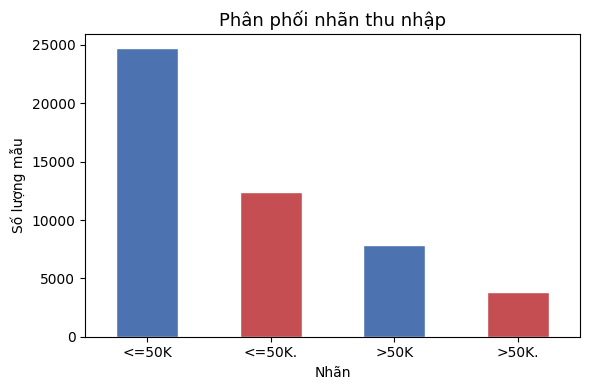

In [5]:
# ============================================================
# Cell 5: Phân phối nhãn — kiểm tra mất cân bằng (imbalance)
# ------------------------------------------------------------
# Bài toán thu nhập thường bị imbalanced: số người <=50K nhiều hơn >50K
# Nếu imbalanced nặng mà không xử lý, model sẽ thiên về nhãn đa số
# ============================================================

label_col = y.columns[0]
label_counts = y[label_col].value_counts()
print("Phân phối nhãn:")
print(label_counts)
print(f"\nTỉ lệ: {label_counts.iloc[1]/label_counts.iloc[0]*100:.1f}% mẫu >50K so với <=50K")

plt.figure(figsize=(6, 4))
label_counts.plot(kind='bar', color=['#4C72B0', '#C44E52'], edgecolor='white')
plt.title("Phân phối nhãn thu nhập", fontsize=13)
plt.xlabel("Nhãn")
plt.ylabel("Số lượng mẫu")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


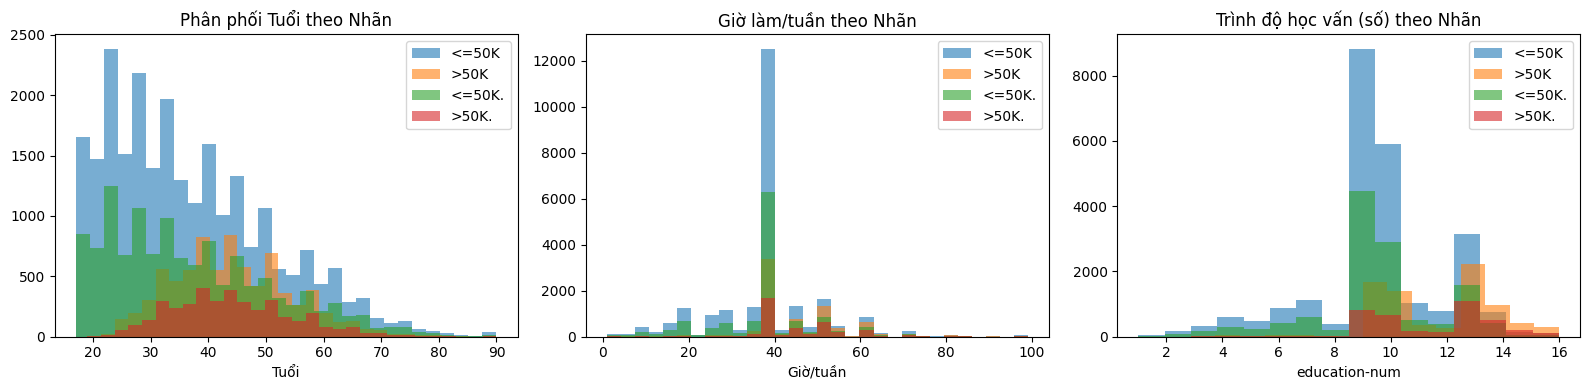

In [6]:
# ============================================================
# Cell 6: Phân tích nhanh một số features quan trọng
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Phân phối tuổi theo nhãn
for label in y[label_col].unique():
    idx = (y[label_col] == label).values
    axes[0].hist(X.loc[idx, 'age'], bins=30, alpha=0.6, label=label)
axes[0].set_title("Phân phối Tuổi theo Nhãn")
axes[0].set_xlabel("Tuổi")
axes[0].legend()

# Giờ làm việc mỗi tuần
for label in y[label_col].unique():
    idx = (y[label_col] == label).values
    axes[1].hist(X.loc[idx, 'hours-per-week'], bins=30, alpha=0.6, label=label)
axes[1].set_title("Giờ làm/tuần theo Nhãn")
axes[1].set_xlabel("Giờ/tuần")
axes[1].legend()

# Trình độ học vấn (education-num)
for label in y[label_col].unique():
    idx = (y[label_col] == label).values
    axes[2].hist(X.loc[idx, 'education-num'], bins=16, alpha=0.6, label=label)
axes[2].set_title("Trình độ học vấn (số) theo Nhãn")
axes[2].set_xlabel("education-num")
axes[2].legend()

plt.tight_layout()
plt.show()


## 2. Tiền xử lý Dữ liệu (Preprocessing)

Pipeline xử lý:
1. Xử lý missing values (điền bằng mode của cột)
2. Label Encoding nhãn `y`: `<=50K` = 0, `>50K` = 1
3. One-Hot Encoding các cột phân loại
4. StandardScaler chuẩn hóa các cột số
5. SMOTE để cân bằng nhãn trên tập train


In [7]:
# ============================================================
# Cell 7: Xử lý missing values
# ------------------------------------------------------------
# Chiến lược: điền bằng mode (giá trị xuất hiện nhiều nhất) của từng cột
# Lý do: các cột bị thiếu đều là categorical, mode phù hợp hơn mean/median
# ============================================================

X_clean = X.copy()

cat_cols = X_clean.select_dtypes(include='object').columns.tolist()
num_cols = X_clean.select_dtypes(include=['int64','float64']).columns.tolist()

print(f"Cột phân loại ({len(cat_cols)}): {cat_cols}")
print(f"Cột số        ({len(num_cols)}): {num_cols}")
print()

# Điền missing bằng mode
for col in cat_cols:
    mode_val = X_clean[col].mode()[0]
    missing  = X_clean[col].isnull().sum()
    if missing > 0:
        X_clean[col].fillna(mode_val, inplace=True)
        print(f"  [{col}]: điền {missing} giá trị thiếu bằng mode='{mode_val}'")

print("\nSau xử lý, missing values còn lại:", X_clean.isnull().sum().sum())


Cột phân loại (8): ['workclass', 'education', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'native-country']
Cột số        (6): ['age', 'fnlwgt', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week']

  [workclass]: điền 963 giá trị thiếu bằng mode='Private'
  [occupation]: điền 966 giá trị thiếu bằng mode='Prof-specialty'
  [native-country]: điền 274 giá trị thiếu bằng mode='United-States'

Sau xử lý, missing values còn lại: 0


In [8]:
# ============================================================
# Cell 8: Mã hóa nhãn y (Label Encoding)
# ------------------------------------------------------------
# Chuyển nhãn chữ sang nhị phân:
#   '<=50K'  =>  0  (thu nhập thấp — nhãn âm)
#   '>50K'   =>  1  (thu nhập cao — nhãn dương)
# Lưu ý: dataset gốc có thể có dấu chấm ở cuối ('<=50K.' và '>50K.')
#         => dùng str.strip() để loại bỏ khoảng trắng/dấu chấm thừa
# ============================================================

y_raw = y[label_col].str.strip().str.replace('.', '', regex=False)
y_encoded = (y_raw == '>50K').astype(int)

print("Phân phối nhãn sau encoding:")
print(y_encoded.value_counts().rename({0: '<=50K (0)', 1: '>50K (1)'}))
print(f"\nTổng mẫu: {len(y_encoded)}")


Phân phối nhãn sau encoding:
income
<=50K (0)    37155
>50K (1)     11687
Name: count, dtype: int64

Tổng mẫu: 48842


In [9]:
# ============================================================
# Cell 9: One-Hot Encoding (cột phân loại) + StandardScaler (cột số)
# ------------------------------------------------------------
# One-Hot: mỗi giá trị category thành cột nhị phân riêng
#   => tránh model hiểu nhầm category có thứ tự số học
# StandardScaler: chuẩn hóa cột số về mean=0, std=1
#   => giúp ANN hội tụ nhanh hơn, không bị lệch vì scale khác nhau
#   (vd: 'age' từ 17-90 vs 'capital-gain' từ 0-99999)
# ============================================================

# Bước 1: One-Hot Encoding cột phân loại
X_encoded = pd.get_dummies(X_clean, columns=cat_cols)

# Bước 2: StandardScaler cho cột số
scaler = StandardScaler()
X_encoded[num_cols] = scaler.fit_transform(X_encoded[num_cols])

print(f"Shape sau encoding: {X_encoded.shape}")
print(f"Số features: {X_encoded.shape[1]}")
print()
print("5 dòng đầu (cột số đã chuẩn hóa, cột phân loại đã one-hot):")
X_encoded.head()


Shape sau encoding: (48842, 108)
Số features: 108

5 dòng đầu (cột số đã chuẩn hóa, cột phân loại đã one-hot):


,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week,workclass_?,workclass_Federal-gov,workclass_Local-gov,workclass_Never-worked,...,native-country_Portugal,native-country_Puerto-Rico,native-country_Scotland,native-country_South,native-country_Taiwan,native-country_Thailand,native-country_Trinadad&Tobago,native-country_United-States,native-country_Vietnam,native-country_Yugoslavia
0,0.025996,-1.061979,1.136512,0.146932,-0.217127,-0.034087,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False
1,0.828308,-1.007104,1.136512,-0.144804,-0.217127,-2.213032,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False
2,-0.046942,0.246034,-0.419335,-0.144804,-0.217127,-0.034087,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False
3,1.047121,0.426663,-1.197259,-0.144804,-0.217127,-0.034087,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False
4,-0.776316,1.408530,1.136512,-0.144804,-0.217127,-0.034087,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


## 3. Chia Tập và Cân bằng Nhãn (SMOTE)

In [10]:
# ============================================================
# Cell 10: Chia tập train/test (80/20, stratified)
# ------------------------------------------------------------
# stratify=y_encoded: giữ tỉ lệ nhãn trong cả train và test
# Quan trọng khi dataset bị imbalanced để test set phản ánh đúng thực tế
# ============================================================

X_arr = X_encoded.values.astype(np.float32)
y_arr = y_encoded.values

X_train, X_test, y_train, y_test = train_test_split(
    X_arr, y_arr,
    test_size=0.2,
    random_state=42,
    stratify=y_arr
)

print(f"Tập train: {X_train.shape[0]:,} mẫu")
print(f"Tập test : {X_test.shape[0]:,} mẫu")
print()
print("Phân phối nhãn trong tập train (trước SMOTE):")
unique, counts = np.unique(y_train, return_counts=True)
for u, c in zip(unique, counts):
    lbl = '>50K' if u == 1 else '<=50K'
    print(f"  {lbl}: {c:,} ({c/len(y_train)*100:.1f}%)")


Tập train: 39,073 mẫu
Tập test : 9,769 mẫu

Phân phối nhãn trong tập train (trước SMOTE):
  <=50K: 29,724 (76.1%)
  >50K: 9,349 (23.9%)


In [11]:
# ============================================================
# Cell 11: SMOTE — cân bằng nhãn trên tập TRAIN
# ------------------------------------------------------------
# SMOTE (Synthetic Minority Over-sampling Technique):
#   Tạo ra mẫu giả (synthetic) cho nhãn thiểu số (>50K)
#   bằng cách nội suy giữa các mẫu gần nhau trong không gian feature
#
# LƯU Ý QUAN TRỌNG:
#   Chỉ áp dụng SMOTE trên tập TRAIN, KHÔNG dùng trên tập TEST
#   Lý do: tập test phải phản ánh đúng phân phối thực tế,
#           không được "làm đẹp" bằng dữ liệu nhân tạo
# ============================================================

smote = SMOTE(random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)

print("Sau SMOTE — phân phối nhãn trong tập train:")
unique, counts = np.unique(y_train_bal, return_counts=True)
for u, c in zip(unique, counts):
    lbl = '>50K' if u == 1 else '<=50K'
    print(f"  {lbl}: {c:,} ({c/len(y_train_bal)*100:.1f}%)")
print(f"\nTổng mẫu train sau SMOTE: {X_train_bal.shape[0]:,}")


Sau SMOTE — phân phối nhãn trong tập train:
  <=50K: 29,724 (50.0%)
  >50K: 29,724 (50.0%)

Tổng mẫu train sau SMOTE: 59,448


## 4. Xây dựng Mô hình ANN

Kiến trúc:
- **Input**: số features sau encoding
- **Hidden 1**: 128 neurons, ReLU + BatchNormalization + Dropout(0.4)
- **Hidden 2**: 64 neurons, ReLU + BatchNormalization + Dropout(0.3)
- **Hidden 3**: 32 neurons, ReLU + Dropout(0.2)
- **Output**: 1 neuron, Sigmoid (phân loại nhị phân)

BatchNormalization: chuẩn hóa đầu ra từng lớp trong quá trình training, giúp model ổn định và học nhanh hơn.


In [12]:
# ============================================================
# Cell 12: Xây dựng kiến trúc ANN
# ------------------------------------------------------------
# Bài toán binary classification => output layer dùng sigmoid
#   sigmoid(x) trả về xác suất trong khoảng (0, 1)
#   ngưỡng mặc định: >= 0.5 => nhãn 1 (>50K)
#
# BatchNormalization: chuẩn hóa activation trong từng mini-batch
#   => giúp gradient flow ổn định, training nhanh và đỡ nhạy cảm với
#      learning rate
# ============================================================

num_features = X_train_bal.shape[1]

model = keras.Sequential([
    # --- Hidden layer 1 ---
    layers.Dense(128, input_shape=(num_features,)),
    layers.BatchNormalization(),   # chuẩn hóa nội bộ lớp
    layers.Activation('relu'),
    layers.Dropout(0.4),           # tắt 40% neurons ngẫu nhiên khi training

    # --- Hidden layer 2 ---
    layers.Dense(64),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.Dropout(0.3),

    # --- Hidden layer 3 ---
    layers.Dense(32, activation='relu'),
    layers.Dropout(0.2),

    # --- Output layer ---
    # 1 neuron + sigmoid => xác suất thuộc nhãn >50K
    layers.Dense(1, activation='sigmoid')
], name="ANN_Adult_Income")

model.summary()


Model: "ANN_Adult_Income"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │        13,952 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 25,089 (98.00 KB)

 Trainable params: 24,705 (96.50 KB)

 Non-trainable params: 384 (1.50 KB)

In [13]:
# ============================================================
# Cell 13: Compile mô hình
# ------------------------------------------------------------
# loss='binary_crossentropy': hàm mất mát chuẩn cho binary classification
#   Đo khoảng cách giữa xác suất dự đoán và nhãn thực (0 hoặc 1)
#
# optimizer=Adam(lr=0.001): learning rate mặc định của Adam
#   Adam tự điều chỉnh learning rate cho từng tham số => hội tụ nhanh
#
# metrics=['accuracy', AUC]: theo dõi cả accuracy và AUC-ROC
#   AUC (Area Under Curve): đo khả năng phân biệt 2 nhãn của model
#   AUC=1.0: hoàn hảo | AUC=0.5: model không tốt hơn đoán ngẫu nhiên
# ============================================================

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy', keras.metrics.AUC(name='auc')]
)

print("Compile thành công!")


Compile thành công!


## 5. Huấn luyện Mô hình

In [14]:
# ============================================================
# Cell 14: Huấn luyện mô hình
# ------------------------------------------------------------
# epochs=100: tối đa 100 lần duyệt qua toàn bộ tập train
# batch_size=256: mỗi bước cập nhật gradient dùng 256 mẫu
#   batch lớn hơn => training nhanh hơn (GPU/CPU utilization tốt)
#   nhưng có thể converge đến local minima ít tốt hơn
#
# validation_split=0.1: trích 10% từ train để theo dõi val_loss
# EarlyStopping(patience=10): dừng sớm nếu val_loss không giảm
#   trong 10 epochs liên tiếp => tiết kiệm thời gian, chống overfitting
# ReduceLROnPlateau: tự giảm learning_rate khi val_loss cao nguyên
#   => giúp model thoát khỏi điểm "kẹt" khi gần hội tụ
# ============================================================

callbacks = [
    keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=10,
        restore_best_weights=True,  # giữ lại trọng số epoch tốt nhất
        verbose=1
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,       # giảm learning_rate xuống còn 50%
        patience=5,
        min_lr=1e-6,
        verbose=1
    )
]

history = model.fit(
    X_train_bal, y_train_bal,
    epochs=100,
    batch_size=256,
    validation_split=0.1,
    callbacks=callbacks,
    verbose=1
)

print(f"\nDừng tại epoch: {len(history.history['loss'])}")


Epoch 1/100
209/209 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.7866 - auc: 0.8710 - loss: 0.4433 - val_accuracy: 0.8979 - val_auc: 0.0000e+00 - val_loss: 0.3692 - learning_rate: 0.0010
Epoch 2/100
209/209 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.8202 - auc: 0.9031 - loss: 0.3866 - val_accuracy: 0.8765 - val_auc: 0.0000e+00 - val_loss: 0.3498 - learning_rate: 0.0010
Epoch 3/100
209/209 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.8280 - auc: 0.9095 - loss: 0.3746 - val_accuracy: 0.8636 - val_auc: 0.0000e+00 - val_loss: 0.3716 - learning_rate: 0.0010
Epoch 4/100
209/209 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8313 - auc: 0.9126 - loss: 0.3681 - val_accuracy: 0.8688 - val_auc: 0.0000e+00 - val_loss: 0.3554 - learning_rate: 0.0010
Epoch 5/100
209/209 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8330 - auc: 0.9138 - loss: 0.3658 - val_accuracy: 0.8639 - val_auc: 0.0000e+00 - val_loss: 0.3651 - learning_rate: 0.0010
Epoch 6/100
209/209 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step -

## 6. Trực quan hóa Quá trình Training

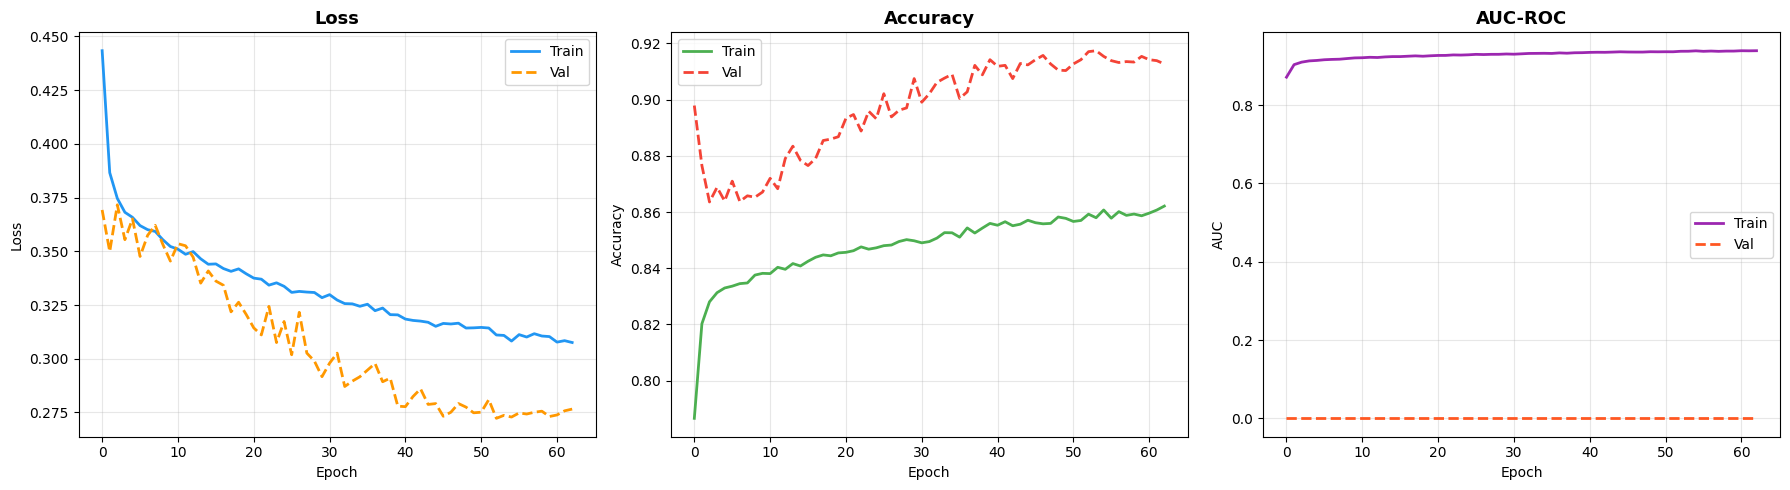

In [15]:
# ============================================================
# Cell 15: Vẽ đồ thị Loss, Accuracy và AUC theo epoch
# ------------------------------------------------------------
# Cách đọc biểu đồ:
#   - train vs val gần nhau => model tổng quát hóa tốt
#   - train giảm nhưng val tăng => bắt đầu overfitting
#   - cả hai đều cao nguyên sớm => có thể cần mô hình phức tạp hơn
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

metrics_to_plot = [
    ('loss',     'val_loss',     'Loss',     'Loss'),
    ('accuracy', 'val_accuracy', 'Accuracy', 'Accuracy'),
    ('auc',      'val_auc',      'AUC-ROC',  'AUC'),
]

colors = [('#2196F3', '#FF9800'), ('#4CAF50', '#F44336'), ('#9C27B0', '#FF5722')]

for ax, (train_key, val_key, title, ylabel), (c1, c2) in zip(axes, metrics_to_plot, colors):
    ax.plot(history.history[train_key], label='Train', color=c1, linewidth=2)
    ax.plot(history.history[val_key],   label='Val',   color=c2, linewidth=2, linestyle='--')
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_xlabel('Epoch')
    ax.set_ylabel(ylabel)
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## 7. Đánh giá Mô hình trên Tập Test

In [16]:
# ============================================================
# Cell 16: Đánh giá tổng quát trên tập TEST
# ------------------------------------------------------------
# Tập test KHÔNG qua SMOTE => phản ánh đúng phân phối thực tế
# Đây là con số quan trọng nhất để báo cáo kết quả
# ============================================================

test_loss, test_acc, test_auc = model.evaluate(X_test, y_test, verbose=0)
print(f"Test Loss    : {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}  ({test_acc*100:.2f}%)")
print(f"Test AUC-ROC : {test_auc:.4f}")


Test Loss    : 0.3683
Test Accuracy: 0.8225  (82.25%)
Test AUC-ROC : 0.9057


In [17]:
# ============================================================
# Cell 17: Dự đoán và chuyển xác suất thành nhãn
# ------------------------------------------------------------
# model.predict() trả về xác suất trong (0, 1) cho nhãn '>50K'
# Ngưỡng 0.5: nếu xác suất >= 0.5 => dự đoán nhãn 1 (>50K)
#             nếu xác suất <  0.5 => dự đoán nhãn 0 (<=50K)
# Có thể điều chỉnh ngưỡng tùy bài toán (vd: 0.3 để tăng recall >50K)
# ============================================================

y_pred_prob = model.predict(X_test, verbose=0).flatten()  # xác suất
y_pred      = (y_pred_prob >= 0.5).astype(int)             # nhãn 0/1

print(f"Tổng mẫu test   : {len(y_test):,}")
print(f"Dự đoán đúng    : {(y_pred == y_test).sum():,}")
print(f"Dự đoán sai     : {(y_pred != y_test).sum():,}")
print()

print("=== Classification Report ===")
print(classification_report(
    y_test, y_pred,
    target_names=['<=50K (0)', '>50K (1)']
))


Tổng mẫu test   : 9,769
Dự đoán đúng    : 8,035
Dự đoán sai     : 1,734

=== Classification Report ===
              precision    recall  f1-score   support

   <=50K (0)       0.94      0.82      0.88      7431
    >50K (1)       0.59      0.82      0.69      2338

    accuracy                           0.82      9769
   macro avg       0.76      0.82      0.78      9769
weighted avg       0.85      0.82      0.83      9769



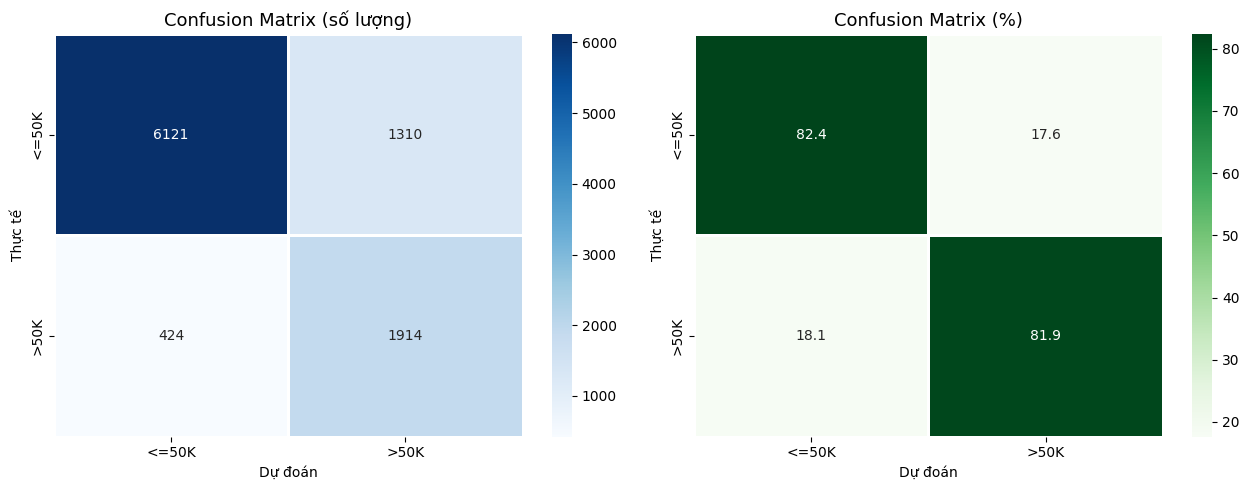

In [18]:
# ============================================================
# Cell 18: Confusion Matrix
# ------------------------------------------------------------
# TP (True Positive) : dự đoán >50K đúng
# TN (True Negative) : dự đoán <=50K đúng
# FP (False Positive): dự đoán >50K nhưng thực tế <=50K (Type I error)
# FN (False Negative): dự đoán <=50K nhưng thực tế >50K (Type II error)
# ============================================================

cm = confusion_matrix(y_test, y_pred)
cm_pct = cm / cm.sum(axis=1, keepdims=True) * 100  # tỉ lệ %

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

# Số lượng tuyệt đối
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['<=50K', '>50K'],
            yticklabels=['<=50K', '>50K'], ax=ax1, linewidths=1)
ax1.set_title('Confusion Matrix (số lượng)', fontsize=13)
ax1.set_xlabel('Dự đoán')
ax1.set_ylabel('Thực tế')

# Tỉ lệ %
sns.heatmap(cm_pct, annot=True, fmt='.1f', cmap='Greens',
            xticklabels=['<=50K', '>50K'],
            yticklabels=['<=50K', '>50K'], ax=ax2, linewidths=1)
ax2.set_title('Confusion Matrix (%)', fontsize=13)
ax2.set_xlabel('Dự đoán')
ax2.set_ylabel('Thực tế')

plt.tight_layout()
plt.show()


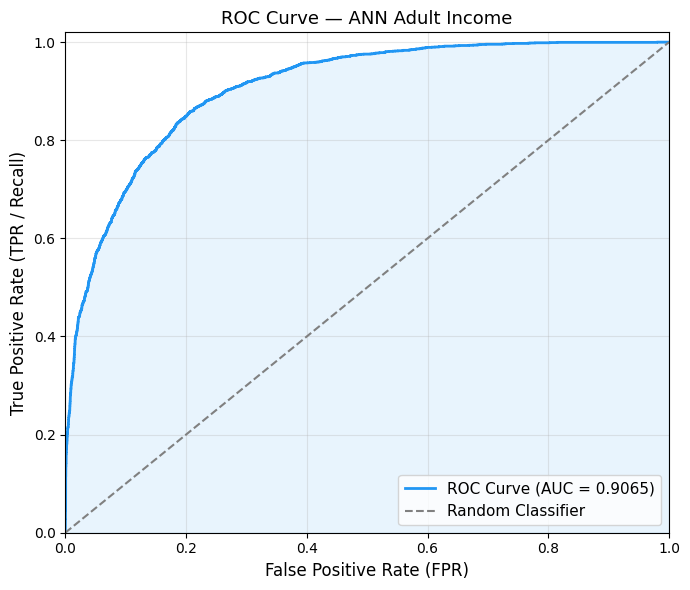

In [19]:
# ============================================================
# Cell 19: Đường cong ROC (Receiver Operating Characteristic)
# ------------------------------------------------------------
# ROC curve: vẽ TPR (True Positive Rate / Recall) vs FPR (False Positive Rate)
#   theo các ngưỡng phân loại khác nhau
# AUC (Area Under Curve): diện tích dưới đường ROC
#   AUC = 1.0 => mô hình hoàn hảo
#   AUC = 0.5 => mô hình đoán ngẫu nhiên (đường chéo)
#   AUC > 0.85 => mô hình tốt
# ============================================================

fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)
auc_score = roc_auc_score(y_test, y_pred_prob)

plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, color='#2196F3', lw=2, label=f'ROC Curve (AUC = {auc_score:.4f})')
plt.plot([0, 1], [0, 1], color='gray', lw=1.5, linestyle='--', label='Random Classifier')
plt.fill_between(fpr, tpr, alpha=0.1, color='#2196F3')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.02])
plt.xlabel('False Positive Rate (FPR)', fontsize=12)
plt.ylabel('True Positive Rate (TPR / Recall)', fontsize=12)
plt.title('ROC Curve — ANN Adult Income', fontsize=13)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## 8. Dự đoán với Dữ liệu Mới

In [20]:
# ============================================================
# Cell 20: Dự đoán thu nhập cho 2 người mới
# ------------------------------------------------------------
# Khi nhập dữ liệu mới, phải thực hiện đúng pipeline:
#   1. Tạo DataFrame đúng tên cột
#   2. Điền giá trị thiếu (nếu có)
#   3. One-Hot Encoding
#   4. Căn chỉnh cột (reindex) khớp với tập train
#   5. StandardScaler trên cột số
#   6. Dự đoán
# ============================================================

# Mẫu 1: Kỹ sư 42 tuổi, học vấn cao, làm nhiều giờ => kỳ vọng >50K
# Mẫu 2: Người 25 tuổi, mới đi làm, học vấn thấp   => kỳ vọng <=50K
samples_raw = pd.DataFrame([
    {
        'age': 42, 'workclass': 'Private', 'fnlwgt': 150000,
        'education': 'Bachelors', 'education-num': 13,
        'marital-status': 'Married-civ-spouse', 'occupation': 'Exec-managerial',
        'relationship': 'Husband', 'race': 'White', 'sex': 'Male',
        'capital-gain': 5000, 'capital-loss': 0,
        'hours-per-week': 55, 'native-country': 'United-States'
    },
    {
        'age': 25, 'workclass': 'Private', 'fnlwgt': 200000,
        'education': 'HS-grad', 'education-num': 9,
        'marital-status': 'Never-married', 'occupation': 'Machine-op-inspct',
        'relationship': 'Own-child', 'race': 'White', 'sex': 'Male',
        'capital-gain': 0, 'capital-loss': 0,
        'hours-per-week': 40, 'native-country': 'United-States'
    }
])

# --- Áp dụng đúng pipeline ---
# Bước 1: One-Hot Encoding
samples_encoded = pd.get_dummies(samples_raw, columns=cat_cols)

# Bước 2: reindex — điền 0 cho cột thiếu, bỏ cột thừa
samples_encoded = samples_encoded.reindex(
    columns=X_encoded.columns, fill_value=0
)

# Bước 3: StandardScaler trên cột số (dùng scaler đã fit từ tập train)
samples_encoded[num_cols] = scaler.transform(samples_encoded[num_cols])

# Bước 4: Dự đoán
pred_prob = model.predict(samples_encoded.values.astype(np.float32), verbose=0).flatten()
pred_label = ['>50K' if p >= 0.5 else '<=50K' for p in pred_prob]

print("=" * 55)
for i, (prob, label) in enumerate(zip(pred_prob, pred_label)):
    print(f"Người {i+1}: tuổi={samples_raw.iloc[i]['age']}, "
          f"education={samples_raw.iloc[i]['education']}, "
          f"giờ/tuần={samples_raw.iloc[i]['hours-per-week']}")
    print(f"  Xác suất >50K : {prob:.4f} ({prob*100:.1f}%)")
    print(f"  Kết quả dự đoán: [{label}]")
    print()


Người 1: tuổi=42, education=Bachelors, giờ/tuần=55
  Xác suất >50K : 0.9775 (97.8%)
  Kết quả dự đoán: [>50K]

Người 2: tuổi=25, education=HS-grad, giờ/tuần=40
  Xác suất >50K : 0.0001 (0.0%)
  Kết quả dự đoán: [<=50K]



## 9. Tóm tắt Pipeline

```
Raw Data (48,842 mẫu, 14 features, có missing values)
    ↓ Xử lý missing: fillna(mode) cho categorical
    ↓ Label Encoding nhãn: <=50K=0, >50K=1
    ↓ One-Hot Encoding categorical features
    ↓ StandardScaler cho numerical features
Dữ liệu sạch
    ↓ Train/Test split (80/20, stratified)
    ↓ SMOTE chỉ trên tập TRAIN (cân bằng nhãn)
ANN: Dense(128)+BN+ReLU+Dropout(0.4)
   → Dense(64)+BN+ReLU+Dropout(0.3)
   → Dense(32)+ReLU+Dropout(0.2)
   → Dense(1, sigmoid)
    ↓ Adam(lr=0.001) + Binary Crossentropy
    ↓ 100 epochs, batch=256, EarlyStopping(patience=10), ReduceLR
Đánh giá: Accuracy | AUC-ROC | Classification Report | Confusion Matrix | ROC Curve
```

**Điểm khác biệt so với bài Car Evaluation:**

| | Car Evaluation | Adult Income |
|--|--|--|
| Loại bài toán | Multi-class (4 nhãn) | Binary (2 nhãn) |
| Output activation | Softmax | Sigmoid |
| Loss function | Sparse Categorical CE | Binary CE |
| Missing values | Không có | Có (3 cột) |
| Imbalanced | Nhẹ | Nặng (SMOTE) |
| Metric thêm | — | AUC-ROC |
